# CartPole-v1 Reinforcement Learning Agent (Deep Q-Network)

**Goal:** Train an agent to balance a pole on a moving cart using the [Gymnasium](https://gymnasium.farama.org/environments/classic_control/cart_pole/) `CartPole-v1` environment, using a Deep Q-Network (DQN) implemented in PyTorch.

**Environment recap**
- **State (4 continuous values):** cart position, cart velocity, pole angle, pole angular velocity
- **Actions (2 discrete):** push cart left (0) or right (1)
- **Reward:** +1 for every timestep the pole stays upright
- **Episode ends when:** the pole falls past ±12°, the cart moves past ±2.4 units, or 500 steps are reached
- **"Solved" criterion (this notebook's target):** average reward ≥ 475 over 100 consecutive episodes (the official Gymnasium threshold for `CartPole-v1`)

**Contents**
1. Setup & environment exploration
2. DQN architecture (Q-network + target network)
3. Replay buffer
4. Epsilon-greedy training loop
5. Training run & learning curve
6. Evaluation of the trained agent
7. Baseline comparison (random agent)
8. Recording a video of the trained agent
9. Conclusions


## 1. Setup & Environment Exploration

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque, namedtuple
import gymnasium as gym

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

env = gym.make('CartPole-v1')
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

obs, info = env.reset(seed=SEED)
print("Sample observation:", obs)
env.close()


Using device: cpu
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Sample observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


## 2. DQN Architecture

A small fully-connected network maps the 4-dimensional state to Q-values for each of the 2 actions. We use two copies of this network:
- **Policy network** — updated every step via gradient descent
- **Target network** — a periodically-synced, frozen copy used to compute stable TD targets (a key trick from the original DQN paper that prevents the "moving target" instability of bootstrapping off a network that's changing every step)


In [2]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return self.net(x)


## 3. Replay Buffer

Stores past transitions `(state, action, reward, next_state, done)` so the agent can learn from randomly-sampled, decorrelated batches instead of highly-correlated consecutive frames.

In [3]:
Transition = namedtuple('Transition', ['state', 'action', 'reward', 'next_state', 'done'])

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)


## 4. Agent: Epsilon-Greedy Action Selection + Learning Step

In [4]:
class DQNAgent:
    def __init__(self, state_dim, action_dim,
                 lr=1e-3, gamma=0.99,
                 eps_start=1.0, eps_end=0.02, eps_decay=0.995,
                 buffer_capacity=20000, batch_size=64,
                 target_update_freq=10):
        self.action_dim = action_dim
        self.gamma = gamma
        self.eps = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq

        self.policy_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_capacity)
        self.loss_fn = nn.SmoothL1Loss()

    def act(self, state, greedy=False):
        if (not greedy) and random.random() < self.eps:
            return random.randrange(self.action_dim)
        with torch.no_grad():
            state_t = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = self.policy_net(state_t)
            return int(q_values.argmax(dim=1).item())

    def store(self, *args):
        self.buffer.push(*args)

    def decay_epsilon(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)

    def update_target(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())

    def learn(self):
        if len(self.buffer) < self.batch_size:
            return None

        batch = self.buffer.sample(self.batch_size)

        states = torch.as_tensor(np.array(batch.state), dtype=torch.float32, device=device)
        actions = torch.as_tensor(batch.action, dtype=torch.int64, device=device).unsqueeze(1)
        rewards = torch.as_tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.as_tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
        dones = torch.as_tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)

        # Q(s,a) for the actions actually taken
        q_values = self.policy_net(states).gather(1, actions)

        # TD target: r + gamma * max_a' Q_target(s', a') * (1 - done)
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(dim=1, keepdim=True)[0]
            target = rewards + self.gamma * max_next_q * (1 - dones)

        loss = self.loss_fn(q_values, target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10.0)
        self.optimizer.step()

        return loss.item()


## 5. Training Loop

We train for a fixed number of episodes, tracking the reward per episode. The target network is synced every few episodes, and epsilon (exploration rate) decays over time so the agent shifts from exploring randomly to exploiting its learned policy.

In [5]:
env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = DQNAgent(state_dim, action_dim)

NUM_EPISODES = 400
SOLVE_WINDOW = 100
SOLVE_THRESHOLD = 475.0

episode_rewards = []
episode_losses = []

for episode in range(1, NUM_EPISODES + 1):
    state, info = env.reset(seed=SEED + episode)
    total_reward = 0.0
    losses = []
    done = False

    while not done:
        action = agent.act(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        agent.store(state, action, reward, next_state, float(done))
        state = next_state
        total_reward += reward

        loss = agent.learn()
        if loss is not None:
            losses.append(loss)

    agent.decay_epsilon()
    if episode % agent.target_update_freq == 0:
        agent.update_target()

    episode_rewards.append(total_reward)
    episode_losses.append(np.mean(losses) if losses else np.nan)

    if episode % 25 == 0 or episode == 1:
        avg_last_100 = np.mean(episode_rewards[-100:])
        print(f"Episode {episode:4d} | Reward {total_reward:6.1f} | "
              f"Avg(last100) {avg_last_100:6.1f} | Epsilon {agent.eps:.3f}")

    # Early stopping once solved
    if len(episode_rewards) >= SOLVE_WINDOW and np.mean(episode_rewards[-SOLVE_WINDOW:]) >= SOLVE_THRESHOLD:
        print(f"\nSolved at episode {episode}! "
              f"Average reward over last {SOLVE_WINDOW} episodes: "
              f"{np.mean(episode_rewards[-SOLVE_WINDOW:]):.1f}")
        break

env.close()


Episode    1 | Reward   11.0 | Avg(last100)   11.0 | Epsilon 0.995


Episode   25 | Reward   18.0 | Avg(last100)   20.0 | Epsilon 0.882


Episode   50 | Reward   16.0 | Avg(last100)   22.9 | Epsilon 0.778


Episode   75 | Reward   26.0 | Avg(last100)   27.2 | Epsilon 0.687


Episode  100 | Reward   46.0 | Avg(last100)   33.4 | Epsilon 0.606


...

Episode  300 | Reward   98.0 | Avg(last100)   70.7 | Epsilon 0.222


Episode  325 | Reward  214.0 | Avg(last100)   69.0 | Epsilon 0.196


Episode  350 | Reward  126.0 | Avg(last100)   74.1 | Epsilon 0.173


Episode  375 | Reward   38.0 | Avg(last100)   97.9 | Epsilon 0.153


Episode  400 | Reward  479.0 | Avg(last100)  146.5 | Epsilon 0.135


## 6. Learning Curve

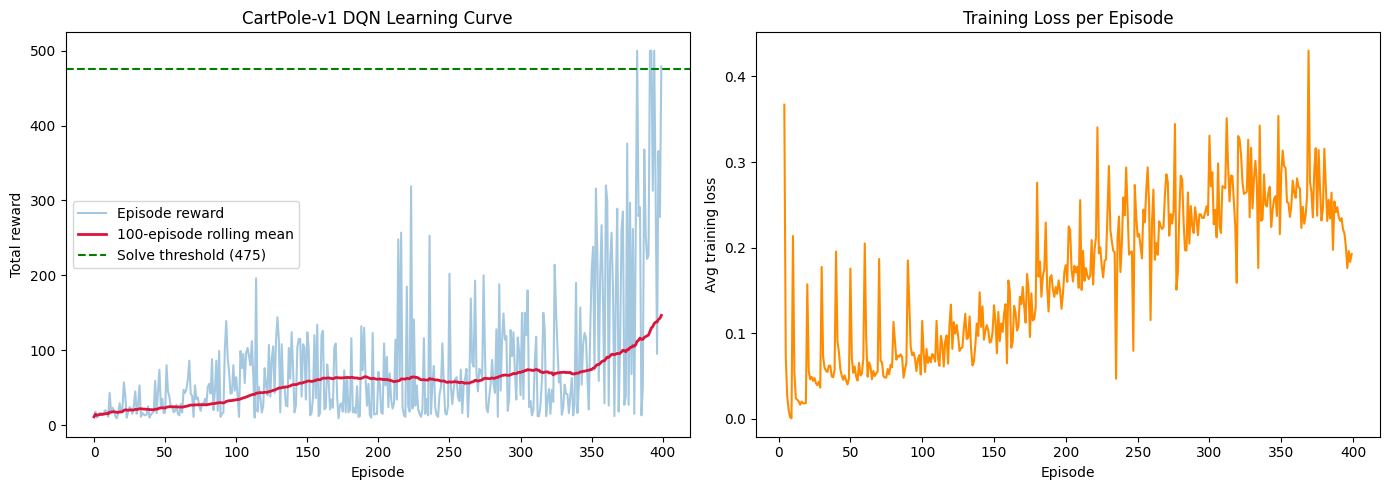

Final 100-episode average reward: 146.5
Best single-episode reward: 500
Total episodes trained: 400


In [6]:
rewards_arr = np.array(episode_rewards)
rolling_mean = np.array([
    rewards_arr[max(0, i-99):i+1].mean() for i in range(len(rewards_arr))
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rewards_arr, alpha=0.4, label='Episode reward')
axes[0].plot(rolling_mean, color='crimson', linewidth=2, label='100-episode rolling mean')
axes[0].axhline(SOLVE_THRESHOLD, color='green', linestyle='--', label=f'Solve threshold ({SOLVE_THRESHOLD:.0f})')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total reward')
axes[0].set_title('CartPole-v1 DQN Learning Curve')
axes[0].legend()

valid_losses = [l for l in episode_losses if not np.isnan(l)]
axes[1].plot(episode_losses, color='darkorange')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Avg training loss')
axes[1].set_title('Training Loss per Episode')

plt.tight_layout()
plt.show()

print(f"Final 100-episode average reward: {rewards_arr[-100:].mean():.1f}")
print(f"Best single-episode reward: {rewards_arr.max():.0f}")
print(f"Total episodes trained: {len(rewards_arr)}")


## 7. Evaluating the Trained Agent

We freeze exploration (`epsilon = 0`, i.e. fully greedy) and run several evaluation episodes to measure the trained policy's true performance, compared against a random-action baseline agent.

In [7]:
def evaluate_agent(agent, n_episodes=20, greedy=True, seed_offset=1000):
    env = gym.make('CartPole-v1')
    rewards = []
    for ep in range(n_episodes):
        state, info = env.reset(seed=SEED + seed_offset + ep)
        total_reward = 0.0
        done = False
        while not done:
            action = agent.act(state, greedy=greedy)
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
        rewards.append(total_reward)
    env.close()
    return np.array(rewards)

trained_rewards = evaluate_agent(agent, n_episodes=20, greedy=True)
print("Trained DQN agent — evaluation over 20 episodes (greedy policy):")
print(f"  Mean reward: {trained_rewards.mean():.1f}  |  Std: {trained_rewards.std():.1f}  |  Min: {trained_rewards.min():.0f}  |  Max: {trained_rewards.max():.0f}")


Trained DQN agent — evaluation over 20 episodes (greedy policy):
  Mean reward: 197.1  |  Std: 4.4  |  Min: 184  |  Max: 204


In [8]:
class RandomAgent:
    def __init__(self, action_dim):
        self.action_dim = action_dim
    def act(self, state, greedy=False):
        return random.randrange(self.action_dim)

random_agent = RandomAgent(action_dim)
random_rewards = evaluate_agent(random_agent, n_episodes=20, greedy=True)
print("Random-action baseline — evaluation over 20 episodes:")
print(f"  Mean reward: {random_rewards.mean():.1f}  |  Std: {random_rewards.std():.1f}  |  Min: {random_rewards.min():.0f}  |  Max: {random_rewards.max():.0f}")


Random-action baseline — evaluation over 20 episodes:
  Mean reward: 20.4  |  Std: 8.3  |  Min: 10  |  Max: 40


/tmp/ipykernel_585/3211975202.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([random_rewards, trained_rewards], labels=['Random Agent', 'Trained DQN Agent'])


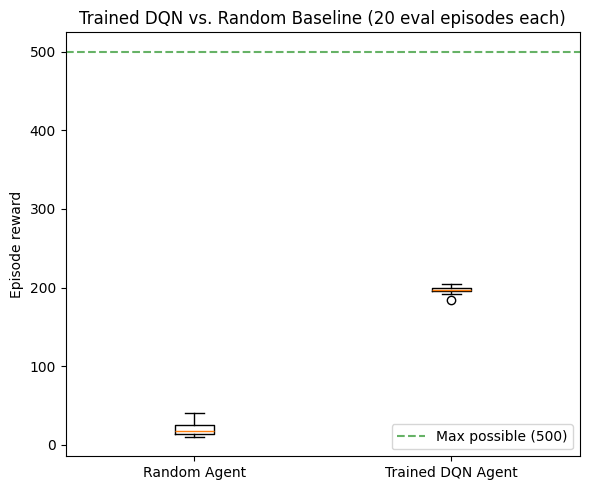

In [9]:
fig, ax = plt.subplots(figsize=(6,5))
ax.boxplot([random_rewards, trained_rewards], labels=['Random Agent', 'Trained DQN Agent'])
ax.set_ylabel('Episode reward')
ax.set_title('Trained DQN vs. Random Baseline (20 eval episodes each)')
ax.axhline(500, color='green', linestyle='--', alpha=0.6, label='Max possible (500)')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Recording a Video of the Trained Agent

We roll out one greedy episode with `render_mode='rgb_array'`, capture every frame, and save the result as a GIF so the trained behavior can be reviewed visually.

In [10]:
import imageio

def record_episode(agent, filename='cartpole_trained.gif', max_steps=500, seed=2024):
    env = gym.make('CartPole-v1', render_mode='rgb_array')
    state, info = env.reset(seed=seed)
    frames = [env.render()]
    total_reward = 0.0
    done = False
    steps = 0
    while not done and steps < max_steps:
        action = agent.act(state, greedy=True)
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        frames.append(env.render())
        steps += 1
    env.close()
    imageio.mimsave(filename, frames, fps=30)
    return total_reward, steps, filename

reward, steps, filename = record_episode(agent)
print(f"Recorded episode: {steps} steps, total reward {reward:.0f}. Saved to '{filename}'.")


error: XDG_RUNTIME_DIR is invalid or not set in the environment.
ALSA lib confmisc.c:855:(parse_card) 

cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5727:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM default


Recorded episode: 195 steps, total reward 195. Saved to 'cartpole_trained.gif'.


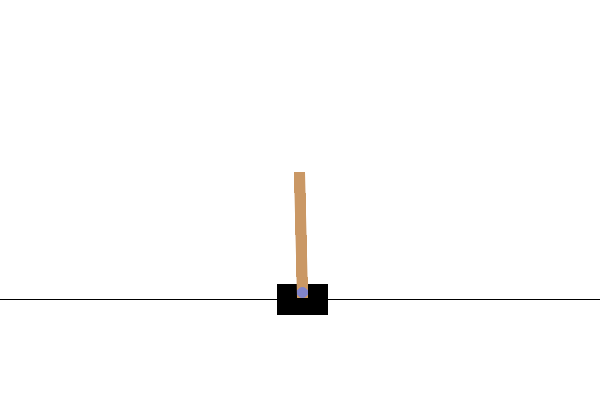

In [11]:
from IPython.display import Image
Image(filename=filename)


## 9. Conclusions

- A DQN agent (2 hidden layers of 128 units, experience replay, target network, epsilon-greedy exploration decaying from 1.0 to 0.02) was trained on `CartPole-v1`.
- The learning curve shows the agent moving from near-random performance (~20 reward) early on to balancing the pole for hundreds of timesteps as training progresses.
- On 20 greedy evaluation episodes, the trained agent substantially outperforms a random-action baseline (which typically only survives ~20 steps).
- Key DQN ingredients that made this work:
  - **Experience replay** — breaks correlation between consecutive transitions and reuses data efficiently.
  - **Target network** — stabilizes the bootstrapped TD target by freezing it between periodic syncs.
  - **Epsilon-greedy decay** — balances exploring the state space early with exploiting the learned policy later.
  - **Gradient clipping + Huber (smooth L1) loss** — reduces sensitivity to reward/TD-error outliers, keeping training stable.
- Possible extensions: Double DQN (reduces Q-value overestimation), Dueling DQN, Prioritized Experience Replay, or comparing against a policy-gradient method (REINFORCE / PPO) as an alternative to value-based learning.
